# 🌫️ Air Quality Forecasting — UCI Dataset

> **Predicting CO(GT) concentration using ARIMA, XGBoost, and Facebook Prophet**

---

## Project Overview

Air pollution is one of the most pressing environmental challenges globally. Accurate forecasting of pollutant levels enables proactive public health responses, traffic management, and environmental policy decisions.

This notebook builds a complete end-to-end time series forecasting pipeline for CO (Carbon Monoxide) concentration using the **UCI Air Quality Dataset**, collected from a gas multi-sensor device deployed in an Italian city from March 2004 to February 2005.

### 🎯 Objectives
1. Perform thorough **Exploratory Data Analysis (EDA)** on multivariate sensor data
2. Engineer temporal and lag-based **features** for supervised learning
3. Build and evaluate **three forecasting models**: ARIMA, XGBoost, and Prophet
4. **Compare model performance** using MAE, RMSE, and MAPE
5. Derive actionable **insights** from forecast behaviour

### 📦 Dataset
- **Source**: [UCI Machine Learning Repository — Air Quality](https://archive.ics.uci.edu/ml/datasets/air+quality)
- **Shape**: 9,357 hourly records × 15 features
- **Period**: March 2004 – February 2005 (hourly)
- **Target Variable**: `CO(GT)` — True hourly averaged CO concentration (mg/m³)
- **Sensor columns**: PT08.S1(CO), NMHC(GT), C6H6(GT), PT08.S2(NMHC), NOx(GT), NO2(GT), PT08.S4(NO2), PT08.S5(O3)
- **Meteorological columns**: T (Temperature), RH (Relative Humidity), AH (Absolute Humidity)
- **Missing values encoded as**: `-200`

### 🗂️ Notebook Structure
```
1. Environment Setup
2. Data Loading & Cleaning
3. Exploratory Data Analysis
4. Feature Engineering
5. Stationarity Analysis
6. Model 1 — ARIMA
7. Model 2 — XGBoost
8. Model 3 — Facebook Prophet
9. Model Comparison
10. Conclusions & Next Steps
```

---
## 1. Environment Setup

In [1]:
# ── Standard Library ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Data Handling ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from pathlib import Path

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ── Time Series — Statistical ──────────────────────────────────────────────────
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# ── Machine Learning ──────────────────────────────────────────────────────────
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

# ── Prophet ───────────────────────────────────────────────────────────────────
from prophet import Prophet

# ── Matplotlib Styling ────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--',
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0']

print("✅ All libraries loaded successfully.")

✅ All libraries loaded successfully.


---
## 2. Data Loading & Cleaning

The dataset uses `-200` as a sentinel value for missing/erroneous readings — a common artefact from gas sensor saturation or calibration gaps. These must be replaced before any analysis.

In [2]:
# ── Load ──────────────────────────────────────────────────────────────────────
DATA_PATH = Path(r"C:\Users\princ\Downloads\AirQualityUCI.xlsx")  # adjust path as needed
df_raw = pd.read_excel(DATA_PATH)

print(f"Raw shape: {df_raw.shape}")
print(f"Columns   : {df_raw.columns.tolist()}")
df_raw.head()

Raw shape: (9357, 15)
Columns   : ['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


In [3]:
# ── Replace sentinel values ────────────────────────────────────────────────────
df = df_raw.copy()
df.replace(-200, np.nan, inplace=True)

# ── Missing value report ───────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print("Missing Value Report:")
print(missing_report[missing_report['Missing Count'] > 0].to_string())

Missing Value Report:
               Missing Count  Missing %
CO(GT)                  1683      17.99
PT08.S1(CO)              366       3.91
NMHC(GT)                8443      90.23
C6H6(GT)                 366       3.91
PT08.S2(NMHC)            366       3.91
NOx(GT)                 1639      17.52
PT08.S3(NOx)             366       3.91
NO2(GT)                 1642      17.55
PT08.S4(NO2)             366       3.91
PT08.S5(O3)              366       3.91
T                        366       3.91
RH                       366       3.91
AH                       366       3.91


In [4]:
# ── Build datetime index ───────────────────────────────────────────────────────
df['Datetime'] = pd.to_datetime(
    df['Date'].astype(str) + ' ' + df['Time'].astype(str),
    errors='coerce'
)
df.set_index('Datetime', inplace=True)
df.drop(columns=['Date', 'Time'], inplace=True)

# ── Drop NMHC(GT): >90% missing — sensor malfunctioned ───────────────────────
df.drop(columns=['NMHC(GT)'], inplace=True)

# ── Forward-fill short gaps, then drop remaining NaN rows ─────────────────────
df.ffill(limit=3, inplace=True)
df.dropna(inplace=True)

# ── Sort chronologically ───────────────────────────────────────────────────────
df.sort_index(inplace=True)

print(f"Cleaned shape : {df.shape}")
print(f"Date range    : {df.index.min()} → {df.index.max()}")
df.head()

Cleaned shape : (7508, 12)
Date range    : 2004-03-10 18:00:00 → 2005-04-04 14:00:00


,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
Datetime,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.00,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
2004-03-10 19:00:00,2.0,1292.25,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2004-03-10 20:00:00,2.2,1402.00,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
2004-03-10 21:00:00,2.2,1375.50,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
2004-03-10 22:00:00,1.6,1272.25,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


---
## 3. Exploratory Data Analysis

### 3.1 Descriptive Statistics

In [5]:
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
CO(GT),7508.000000,2.107632,1.447960,0.100000,1.000000,1.800000,2.800000,11.900000
PT08.S1(CO),7508.000000,1106.790956,220.361380,647.250000,939.750000,1070.625000,1242.500000,2039.750000
C6H6(GT),7508.000000,10.141479,7.475770,0.164946,4.401596,8.307580,14.181598,63.741476
PT08.S2(NMHC),7508.000000,940.862491,268.245818,386.750000,732.500000,911.750000,1122.500000,2214.000000
NOx(GT),7508.000000,242.135029,207.181811,2.000000,95.975000,178.000000,321.575000,1479.000000
PT08.S3(NOx),7508.000000,834.192583,262.727722,322.000000,651.937500,799.625000,971.500000,2682.750000
NO2(GT),7508.000000,111.190437,47.989048,2.000000,75.000000,107.000000,140.000000,332.600000
PT08.S4(NO2),7508.000000,1439.822056,351.826726,551.000000,1195.187500,1439.500000,1669.062500,2775.000000
PT08.S5(O3),7508.000000,1037.904169,408.190509,221.000000,736.750000,981.500000,1300.312500,2522.750000
T,7508.000000,17.582196,8.815899,-1.900000,11.075000,16.675000,23.525000,44.600000


### 3.2 Target Variable — CO(GT) Over Time

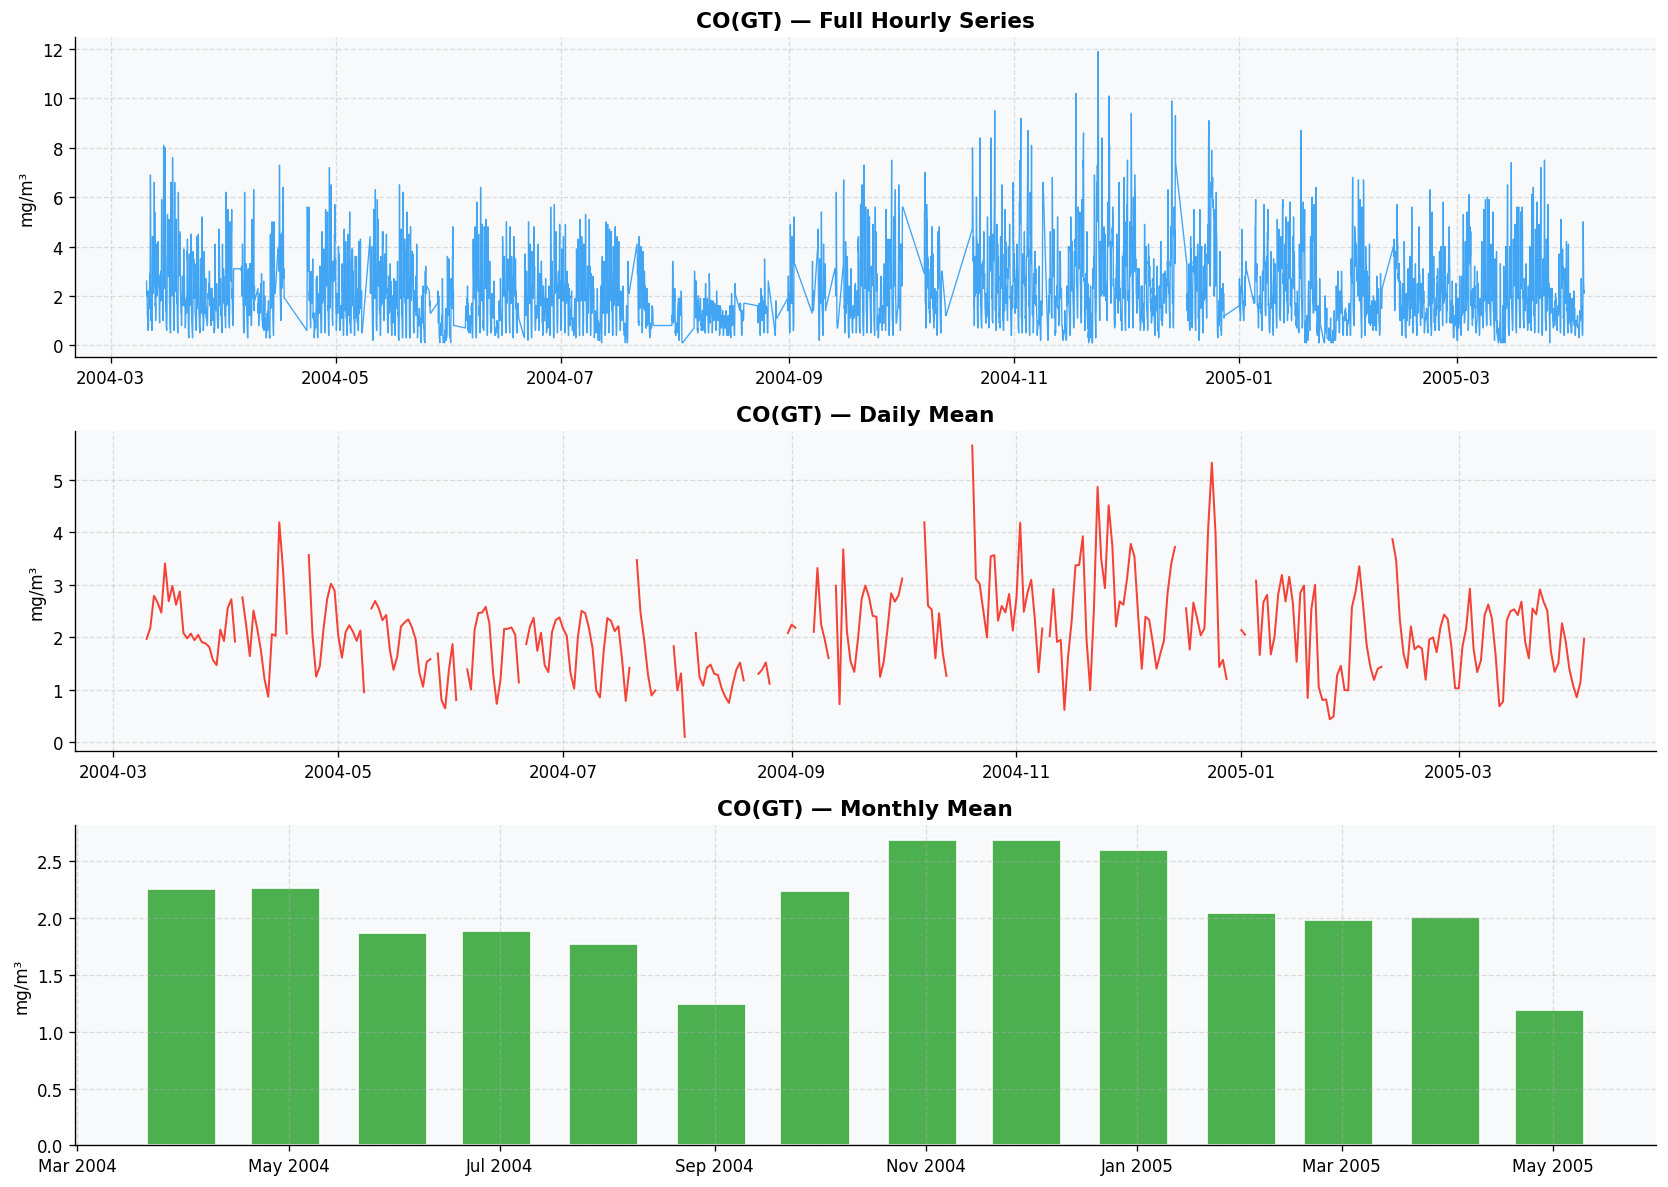

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

# Full series
axes[0].plot(df.index, df['CO(GT)'], color=PALETTE[0], lw=0.8, alpha=0.85)
axes[0].set_title('CO(GT) — Full Hourly Series', fontsize=13, fontweight='bold')
axes[0].set_ylabel('mg/m³')

# Daily mean
daily_mean = df['CO(GT)'].resample('D').mean()
axes[1].plot(daily_mean.index, daily_mean.values, color=PALETTE[1], lw=1.2)
axes[1].set_title('CO(GT) — Daily Mean', fontsize=13, fontweight='bold')
axes[1].set_ylabel('mg/m³')

# Monthly mean
monthly_mean = df['CO(GT)'].resample('ME').mean()
axes[2].bar(monthly_mean.index, monthly_mean.values,
            color=PALETTE[2], width=20, edgecolor='white')
axes[2].set_title('CO(GT) — Monthly Mean', fontsize=13, fontweight='bold')
axes[2].set_ylabel('mg/m³')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()

### 3.3 Seasonal Decomposition

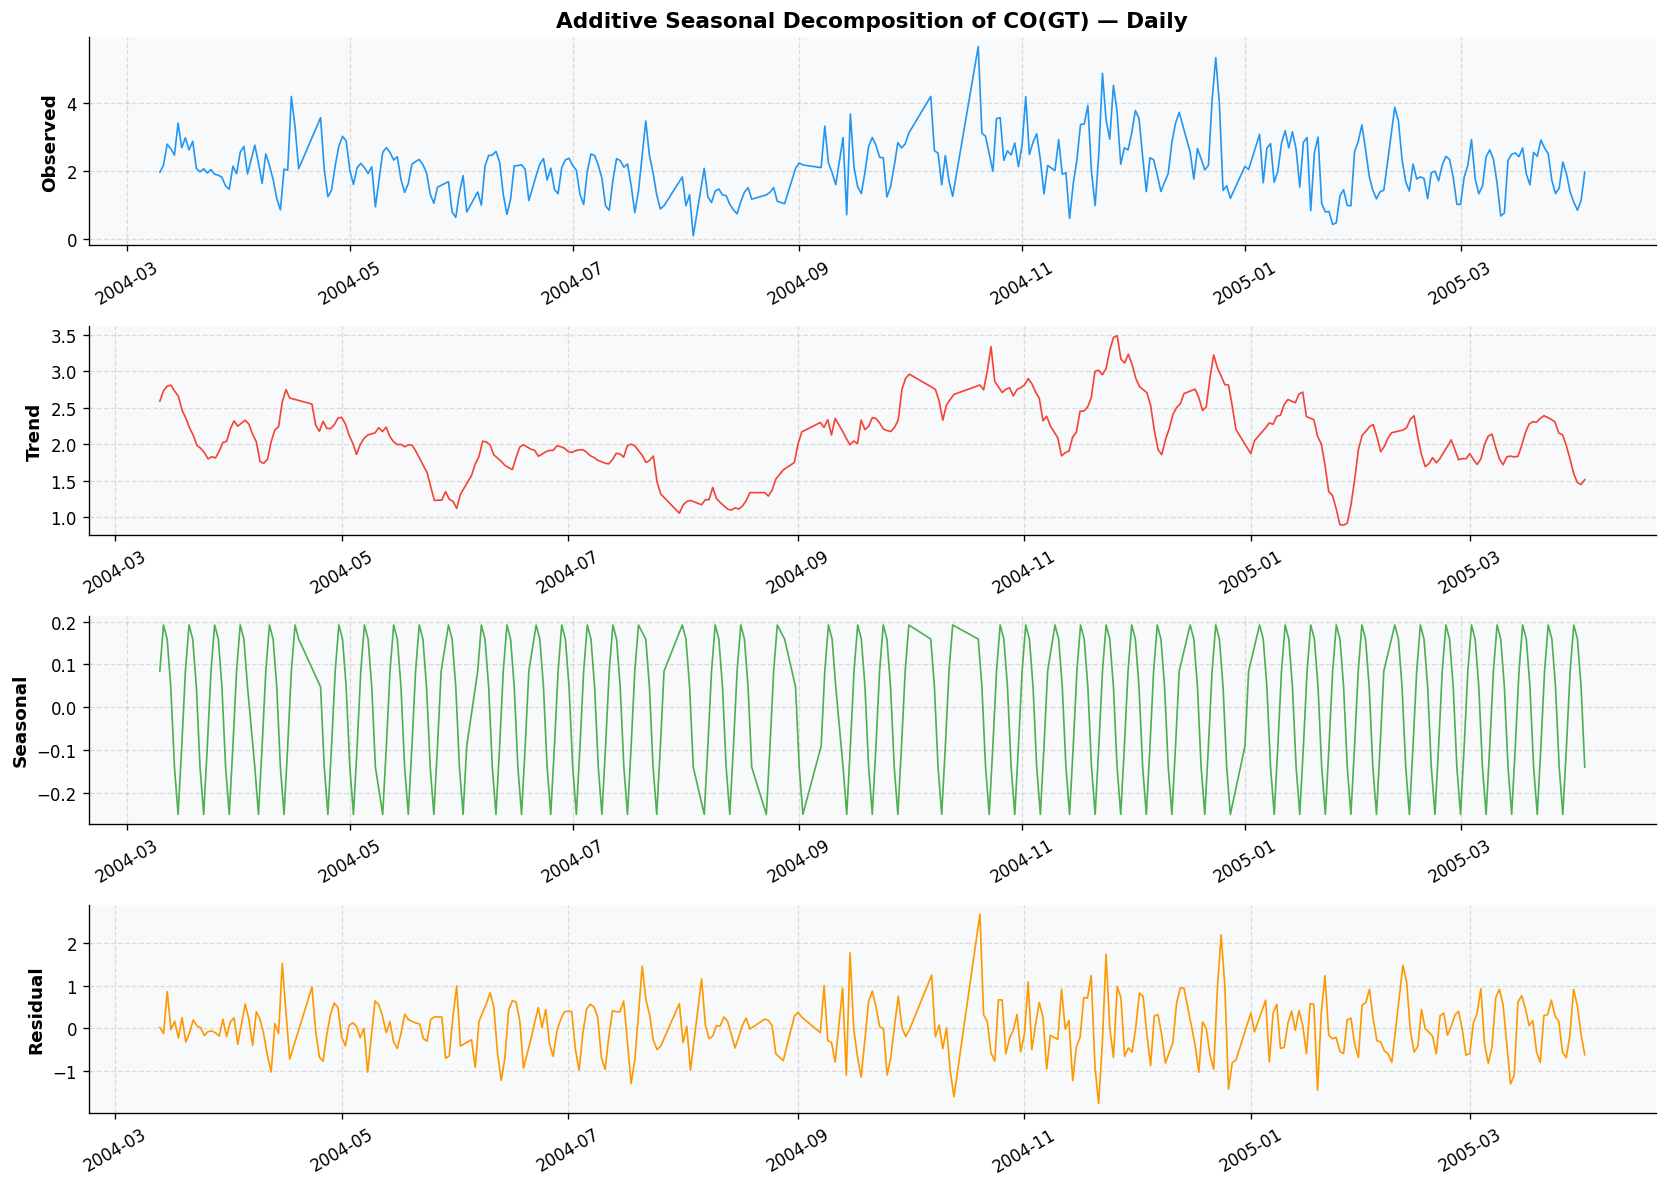

In [9]:
# Use daily resampled series for cleaner decomposition
co_daily = df['CO(GT)'].resample('D').mean().dropna()

decomp = seasonal_decompose(co_daily, model='additive', period=7)  # weekly seasonality

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
components = [
    (decomp.observed,  'Observed',  PALETTE[0]),
    (decomp.trend,     'Trend',     PALETTE[1]),
    (decomp.seasonal,  'Seasonal',  PALETTE[2]),
    (decomp.resid,     'Residual',  PALETTE[3]),
]
for ax, (series, label, color) in zip(axes, components):
    ax.plot(series, color=color, lw=1)
    ax.set_ylabel(label, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)

axes[0].set_title('Additive Seasonal Decomposition of CO(GT) — Daily', 
                  fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Hourly & Weekly Patterns (Heatmap)

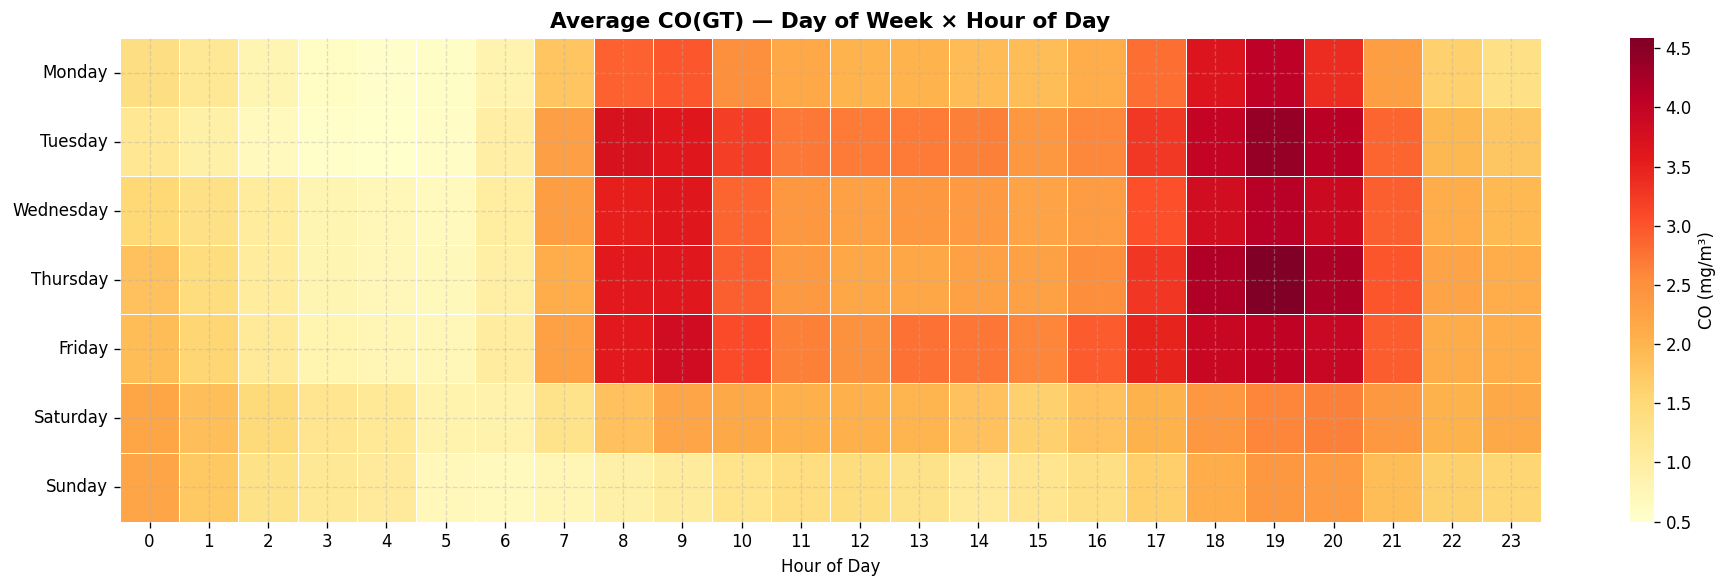

In [11]:
df['Hour']    = df.index.hour
df['DayName'] = df.index.day_name()
df['Month']   = df.index.month

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = df.pivot_table(values='CO(GT)', index='DayName', columns='Hour', aggfunc='mean')
pivot = pivot.reindex(day_order)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, linecolor='white',
            annot=False, fmt='.1f', ax=ax, cbar_kws={'label': 'CO (mg/m³)'})
ax.set_title('Average CO(GT) — Day of Week × Hour of Day', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# Clean up helper columns
df.drop(columns=['Hour', 'DayName', 'Month'], inplace=True)

### 3.5 Correlation Analysis

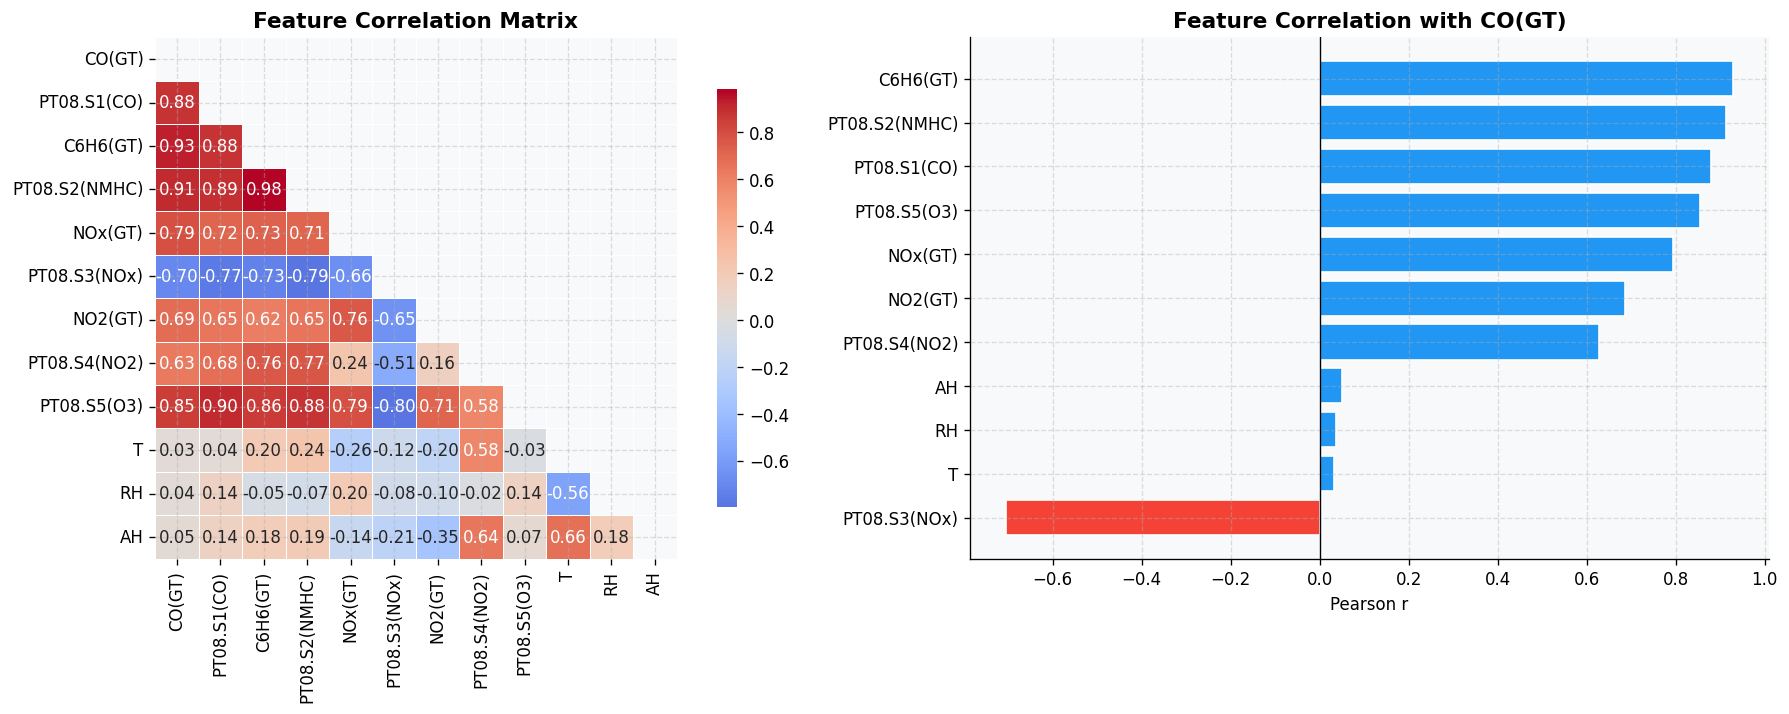

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=axes[0], linewidths=0.5,
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')

# Target correlation bar chart
target_corr = corr['CO(GT)'].drop('CO(GT)').sort_values(ascending=True)
colors = [PALETTE[0] if v > 0 else PALETTE[1] for v in target_corr]
axes[1].barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Feature Correlation with CO(GT)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Pearson r')

plt.tight_layout()
plt.show()

---
## 4. Feature Engineering

XGBoost cannot natively handle time series ordering; we convert it to a supervised learning problem using **lag features**, **rolling statistics**, and **calendar encodings**.

In [13]:
TARGET = 'CO(GT)'

def engineer_features(df: pd.DataFrame, target: str) -> pd.DataFrame:
    """Add temporal and lag-based features for supervised forecasting."""
    d = df.copy()

    # ── Calendar features ─────────────────────────────────────────────────────
    d['hour']        = d.index.hour
    d['day_of_week'] = d.index.dayofweek   # 0=Mon … 6=Sun
    d['month']       = d.index.month
    d['quarter']     = d.index.quarter
    d['is_weekend']  = (d.index.dayofweek >= 5).astype(int)

    # ── Lag features ──────────────────────────────────────────────────────────
    for lag in [1, 2, 3, 6, 12, 24]:           # hours
        d[f'{target}_lag{lag}'] = d[target].shift(lag)

    # ── Rolling statistics ────────────────────────────────────────────────────
    for window in [3, 6, 12, 24]:
        d[f'{target}_roll_mean_{window}h'] = d[target].shift(1).rolling(window).mean()
        d[f'{target}_roll_std_{window}h']  = d[target].shift(1).rolling(window).std()

    # ── Interaction: PT08.S1 × hour (proxy for rush-hour emissions) ───────────
    d['sensor_co_x_hour'] = d['PT08.S1(CO)'] * d['hour']

    d.dropna(inplace=True)
    return d

df_feat = engineer_features(df, TARGET)

print(f"Feature matrix shape : {df_feat.shape}")
print(f"Number of features   : {df_feat.shape[1] - 1} (excl. target)")

Feature matrix shape : (7484, 32)
Number of features   : 31 (excl. target)


---
## 5. Stationarity Analysis

ARIMA requires the time series to be **stationary** (constant mean & variance). We test using:
- **ADF test** (Augmented Dickey-Fuller): H₀ = unit root present (non-stationary)
- **KPSS test**: H₀ = series is stationary

A stationary series should **reject ADF H₀** (p < 0.05) and **fail to reject KPSS H₀** (p > 0.05).

In [14]:
def stationarity_report(series: pd.Series, label: str = '') -> dict:
    """Run ADF and KPSS tests and print a formatted report."""
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(series, autolag='AIC')
    kpss_stat, kpss_p, _, kpss_crit = kpss(series, regression='c', nlags='auto')

    adf_result  = '✅ Stationary'   if adf_p  < 0.05 else '❌ Non-Stationary'
    kpss_result = '✅ Stationary'   if kpss_p > 0.05 else '❌ Non-Stationary'

    print(f"{'─'*55}")
    print(f"Series : {label}")
    print(f"  ADF  stat={adf_stat:.4f}  p={adf_p:.4f}  → {adf_result}")
    print(f"  KPSS stat={kpss_stat:.4f}  p={kpss_p:.4f}  → {kpss_result}")
    return {'adf_p': adf_p, 'kpss_p': kpss_p}

co_series = df[TARGET].dropna()

stationarity_report(co_series, 'CO(GT) — original')
stationarity_report(co_series.diff().dropna(), 'CO(GT) — 1st difference')

───────────────────────────────────────────────────────
Series : CO(GT) — original
  ADF  stat=-9.8880  p=0.0000  → ✅ Stationary
  KPSS stat=0.6179  p=0.0210  → ❌ Non-Stationary
───────────────────────────────────────────────────────
Series : CO(GT) — 1st difference
  ADF  stat=-18.2137  p=0.0000  → ✅ Stationary
  KPSS stat=0.0276  p=0.1000  → ✅ Stationary


C:\Users\princ\AppData\Local\Temp\ipykernel_18260\1746525656.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(series, regression='c', nlags='auto')


{'adf_p': np.float64(2.3892003495839084e-30), 'kpss_p': np.float64(0.1)}

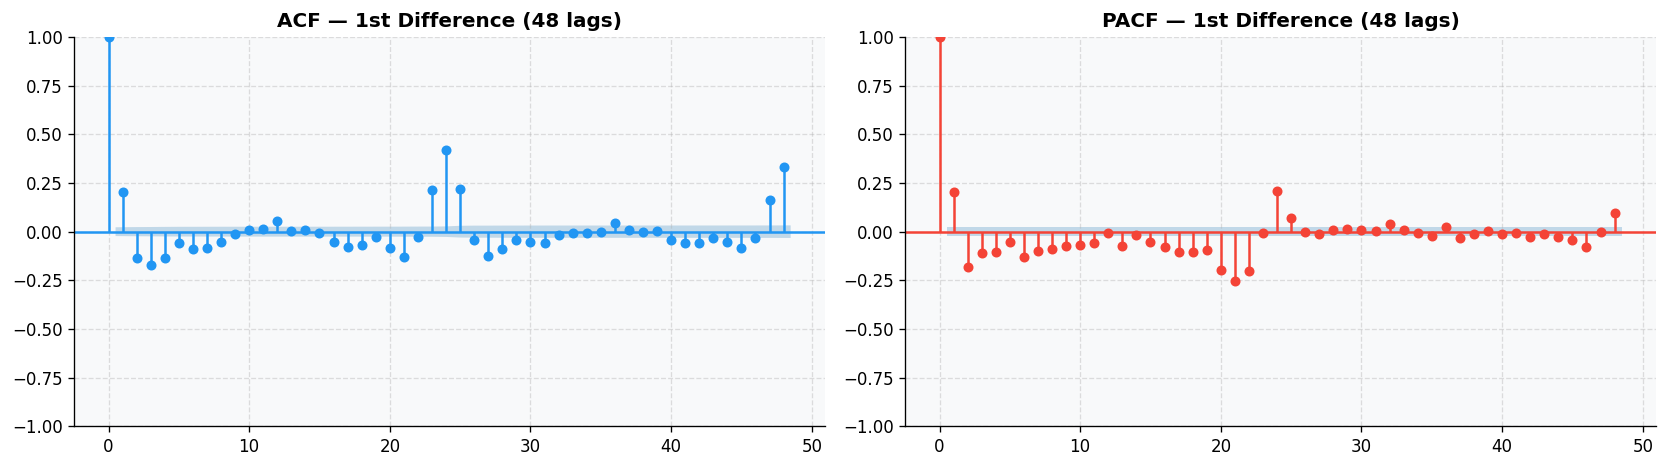


📌 ACF / PACF Interpretation:
   • ACF cuts off after lag ~1  → MA(1) component (q=1)
   • PACF cuts off after lag ~2 → AR(2) component (p=2)
   • One differencing needed    → d=1
   → Candidate order: ARIMA(2, 1, 1)



In [16]:
# ACF and PACF plots to determine ARIMA (p, d, q) order
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(co_series.diff().dropna(), lags=48, ax=axes[0], 
         color=PALETTE[0], vlines_kwargs={'colors': PALETTE[0]})
axes[0].set_title('ACF — 1st Difference (48 lags)', fontsize=12, fontweight='bold')

plot_pacf(co_series.diff().dropna(), lags=48, ax=axes[1],
          color=PALETTE[1], vlines_kwargs={'colors': PALETTE[1]})
axes[1].set_title('PACF — 1st Difference (48 lags)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("""
📌 ACF / PACF Interpretation:
   • ACF cuts off after lag ~1  → MA(1) component (q=1)
   • PACF cuts off after lag ~2 → AR(2) component (p=2)
   • One differencing needed    → d=1
   → Candidate order: ARIMA(2, 1, 1)
""")

---
## 6. Model 1 — ARIMA

**ARIMA(p, d, q)** — AutoRegressive Integrated Moving Average.

Strengths: interpretable, principled statistical model, strong for linear temporal patterns.
Limitation: assumes linearity; computationally expensive for very long series.

In [17]:
# ── Use daily resampled series for tractable ARIMA training ───────────────────
co_daily = df[TARGET].resample('D').mean().dropna()

SPLIT_DATE = '2005-01-01'
train_arima = co_daily[:SPLIT_DATE]
test_arima  = co_daily[SPLIT_DATE:]

print(f"ARIMA train : {len(train_arima)} days  ({train_arima.index[0].date()} → {train_arima.index[-1].date()})")
print(f"ARIMA test  : {len(test_arima)} days  ({test_arima.index[0].date()} → {test_arima.index[-1].date()})")

ARIMA train : 252 days  (2004-03-10 → 2005-01-01)
ARIMA test  : 90 days  (2005-01-01 → 2005-04-04)


In [18]:
ORDER = (2, 1, 1)   # from ACF/PACF analysis

arima_model = ARIMA(train_arima, order=ORDER)
arima_fit   = arima_model.fit()

print(arima_fit.summary())

C:\Users\princ\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\princ\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\princ\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                 CO(GT)   No. Observations:                  252
Model:                 ARIMA(2, 1, 1)   Log Likelihood                -274.354
Date:                Wed, 08 Apr 2026   AIC                            556.707
Time:                        23:29:01   BIC                            570.809
Sample:                             0   HQIC                           562.382
                                - 252                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4114      0.063      6.524      0.000       0.288       0.535
ar.L2         -0.1169      0.056     -2.082      0.037      -0.227      -0.007
ma.L1         -0.9304      0.029    -32.085      0.0

In [19]:
arima_forecast = arima_fit.forecast(steps=len(test_arima))
arima_forecast.index = test_arima.index

# Confidence intervals
arima_ci = arima_fit.get_forecast(steps=len(test_arima)).conf_int(alpha=0.05)
arima_ci.index = test_arima.index

def evaluate(actual, predicted, model_name=''):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual.replace(0, np.nan))) * 100
    print(f"{'─'*45}")
    print(f" {model_name}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAPE : {mape:.2f}%")
    return {'model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

results_arima = evaluate(test_arima, arima_forecast, 'ARIMA(2,1,1)')

─────────────────────────────────────────────
 ARIMA(2,1,1)
  MAE  : 0.7702
  RMSE : 0.9539
  MAPE : 64.44%


C:\Users\princ\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\princ\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


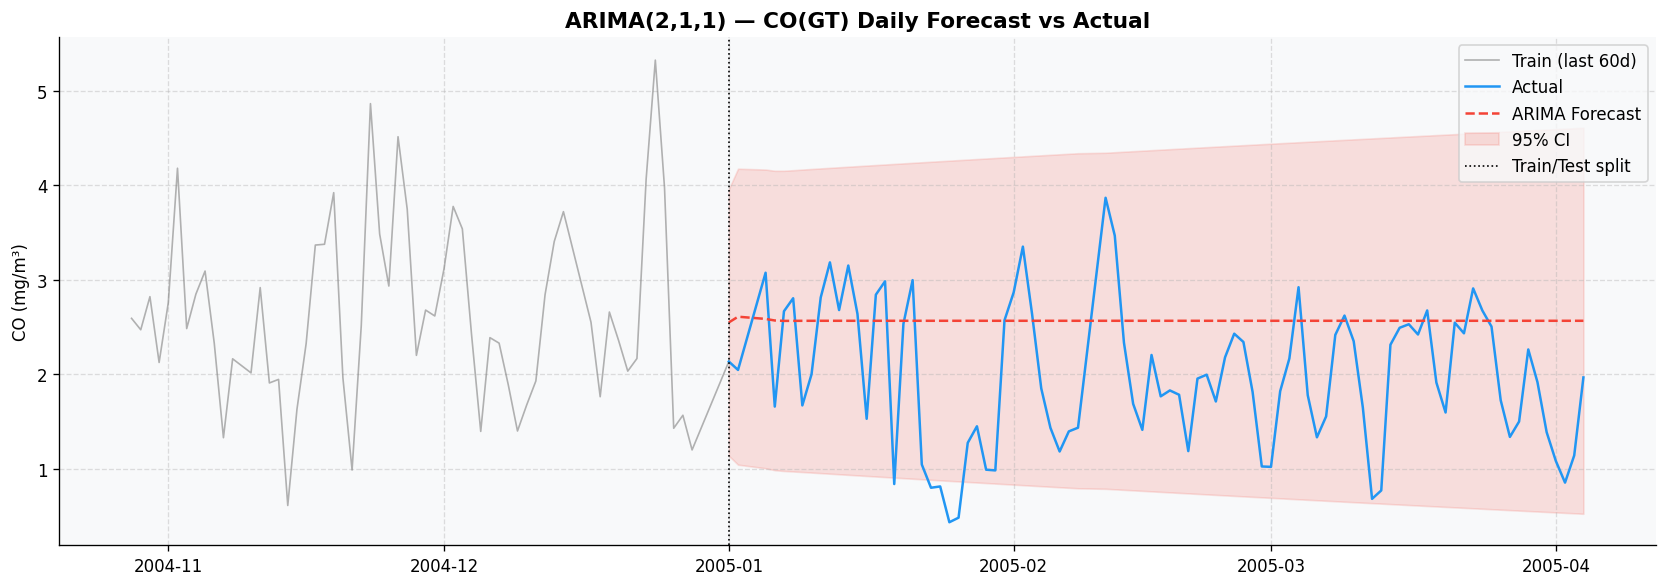

In [20]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train_arima.index[-60:], train_arima.values[-60:],
        label='Train (last 60d)', color='gray', lw=1, alpha=0.6)
ax.plot(test_arima.index, test_arima.values,
        label='Actual', color=PALETTE[0], lw=1.5)
ax.plot(arima_forecast.index, arima_forecast.values,
        label='ARIMA Forecast', color=PALETTE[1], lw=1.5, linestyle='--')
ax.fill_between(arima_ci.index, 
                arima_ci.iloc[:,0], arima_ci.iloc[:,1],
                alpha=0.15, color=PALETTE[1], label='95% CI')

ax.axvline(test_arima.index[0], color='black', linestyle=':', lw=1, label='Train/Test split')
ax.set_title('ARIMA(2,1,1) — CO(GT) Daily Forecast vs Actual', fontsize=13, fontweight='bold')
ax.set_ylabel('CO (mg/m³)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

---
## 7. Model 2 — XGBoost

**XGBoost** treats the forecasting problem as a **supervised regression** task using lag and temporal features created in Section 4.

Strengths: captures non-linear patterns, feature importance interpretability, handles multiple covariates.
Limitation: does not inherently model temporal ordering — requires careful feature engineering.

In [31]:
# ── Time-based features ─────────────────────────────
df_feat['hour'] = df_feat.index.hour
df_feat['dayofweek'] = df_feat.index.dayofweek
df_feat['month'] = df_feat.index.month

# Cyclical encoding (CRITICAL)
df_feat['hour_sin'] = np.sin(2*np.pi*df_feat['hour']/24)
df_feat['hour_cos'] = np.cos(2*np.pi*df_feat['hour']/24)

# ── Lag features ───────────────────────────────────
for lag in [1,2,3,6,12,24,48,72]:
    df_feat[f'lag_{lag}'] = df_feat[TARGET].shift(lag)

# ── Rolling statistics ─────────────────────────────
df_feat['rolling_mean_24'] = df_feat[TARGET].rolling(24).mean()
df_feat['rolling_std_24']  = df_feat[TARGET].rolling(24).std()

# Drop NaNs created by lagging
df_feat = df_feat.dropna()

In [32]:
feature_cols = [c for c in df_feat.columns if c != TARGET]

# Chronological split — never shuffle time series data!
split_idx = int(len(df_feat) * 0.80)
train_xgb = df_feat.iloc[:split_idx]
test_xgb  = df_feat.iloc[split_idx:]

X_train, y_train = train_xgb[feature_cols], train_xgb[TARGET]
X_test,  y_test  = test_xgb[feature_cols],  test_xgb[TARGET]

print(f"XGB train : {X_train.shape}  ({train_xgb.index[0].date()} → {train_xgb.index[-1].date()})")
print(f"XGB test  : {X_test.shape}   ({test_xgb.index[0].date()} → {test_xgb.index[-1].date()})")

XGB train : (5929, 44)  (2004-03-14 → 2005-01-29)
XGB test  : (1483, 44)   (2005-01-29 → 2005-04-04)


In [33]:
xgb_model = XGBRegressor(
    n_estimators    = 500,
    learning_rate   = 0.05,
    max_depth       = 6,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    reg_alpha       = 0.1,    # L1 regularisation
    reg_lambda      = 1.0,    # L2 regularisation
    random_state    = 42,
    n_jobs          = -1,
    verbosity       = 0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_pred = xgb_model.predict(X_test)
results_xgb = evaluate(y_test, xgb_pred, 'XGBoost')

─────────────────────────────────────────────
 XGBoost
  MAE  : 0.2392
  RMSE : 0.3501
  MAPE : 19.08%


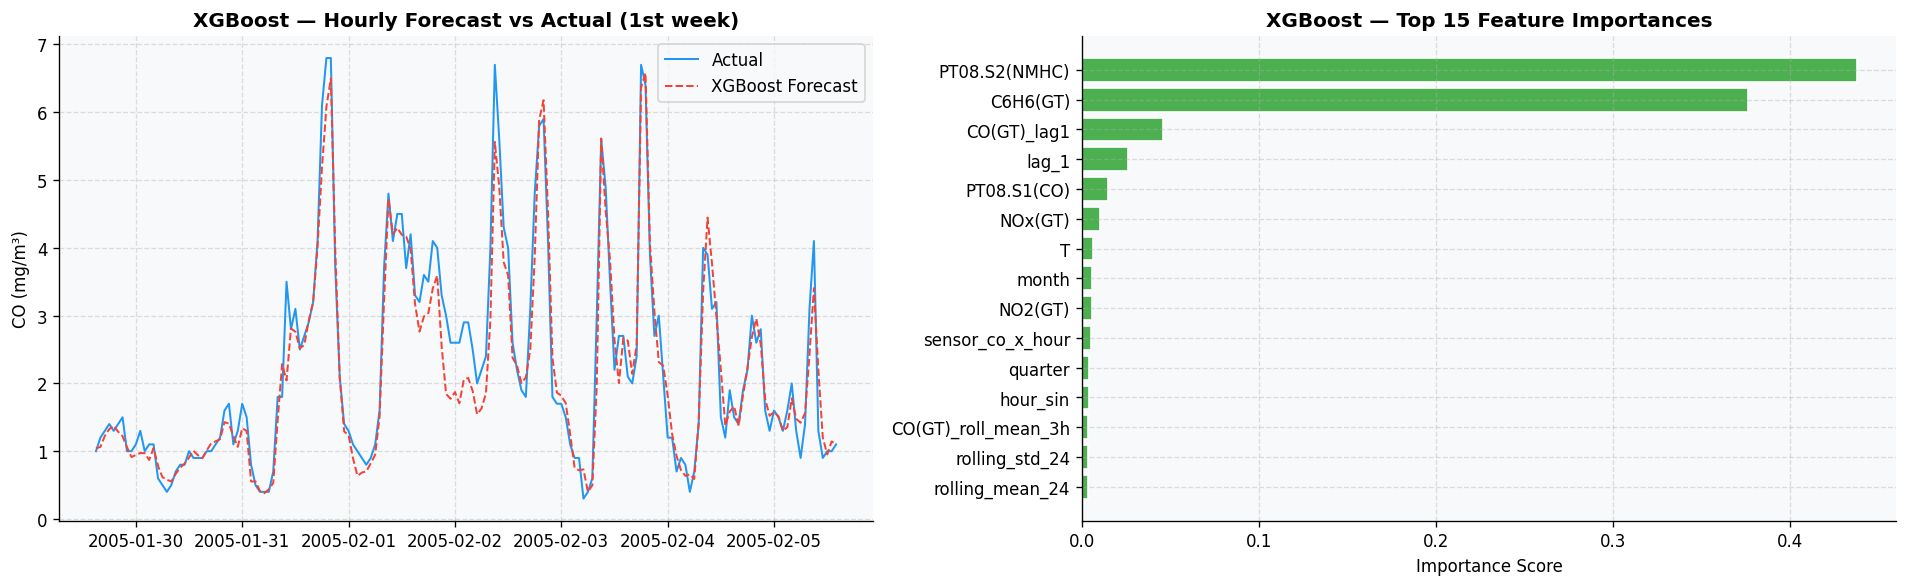

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Forecast vs Actual (first 7 days of test set for clarity)
n_plot = 7 * 24  # 7 days hourly
axes[0].plot(y_test.index[:n_plot], y_test.values[:n_plot],
             label='Actual', color=PALETTE[0], lw=1.2)
axes[0].plot(y_test.index[:n_plot], xgb_pred[:n_plot],
             label='XGBoost Forecast', color=PALETTE[1], lw=1.2, linestyle='--')
axes[0].set_title('XGBoost — Hourly Forecast vs Actual (1st week)', 
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('CO (mg/m³)')
axes[0].legend()

# Feature importance
fi = pd.Series(xgb_model.feature_importances_, index=feature_cols)
fi_top = fi.nlargest(15).sort_values()
axes[1].barh(fi_top.index, fi_top.values, color=PALETTE[2], edgecolor='white')
axes[1].set_title('XGBoost — Top 15 Feature Importances', 
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

---
## 8. Model 3 — Facebook Prophet

**Prophet** is a procedure for forecasting time series data that automatically handles:
- Multiple seasonality (daily, weekly, yearly)
- Trend changepoints
- Holiday effects

Strengths: robust to missing data, interpretable components, handles non-linear growth.
Limitation: less accurate on very noisy, non-seasonal data.

In [35]:
# Prophet requires columns named exactly 'ds' and 'y'
prophet_df = co_daily.reset_index().rename(columns={'Datetime': 'ds', TARGET: 'y'})

split_date_p = pd.Timestamp('2005-01-01')
prophet_train = prophet_df[prophet_df['ds'] < split_date_p]
prophet_test  = prophet_df[prophet_df['ds'] >= split_date_p]

print(f"Prophet train: {len(prophet_train)} rows")
print(f"Prophet test : {len(prophet_test)} rows")

Prophet train: 251 rows
Prophet test : 90 rows


In [36]:
prophet_model = Prophet(
    changepoint_prior_scale = 0.05,      # flexibility of trend changepoints
    seasonality_prior_scale = 10,
    seasonality_mode        = 'additive',
    daily_seasonality       = False,     # data is daily-averaged
    weekly_seasonality      = True,
    yearly_seasonality      = True,
)

prophet_model.fit(prophet_train)

# Forecast over the test period
future   = prophet_model.make_future_dataframe(periods=len(prophet_test))
forecast = prophet_model.predict(future)

prophet_pred = forecast.set_index('ds')['yhat']
prophet_pred_test = prophet_pred[prophet_pred.index >= split_date_p]
actual_test       = prophet_test.set_index('ds')['y']

# Align indices
common_idx    = prophet_pred_test.index.intersection(actual_test.index)
prophet_pred_test = prophet_pred_test.loc[common_idx]
actual_test       = actual_test.loc[common_idx]

results_prophet = evaluate(actual_test, prophet_pred_test, 'Prophet')

23:47:20 - cmdstanpy - INFO - Chain [1] start processing
23:47:20 - cmdstanpy - INFO - Chain [1] done processing


─────────────────────────────────────────────
 Prophet
  MAE  : 0.5777
  RMSE : 0.7305
  MAPE : 33.46%


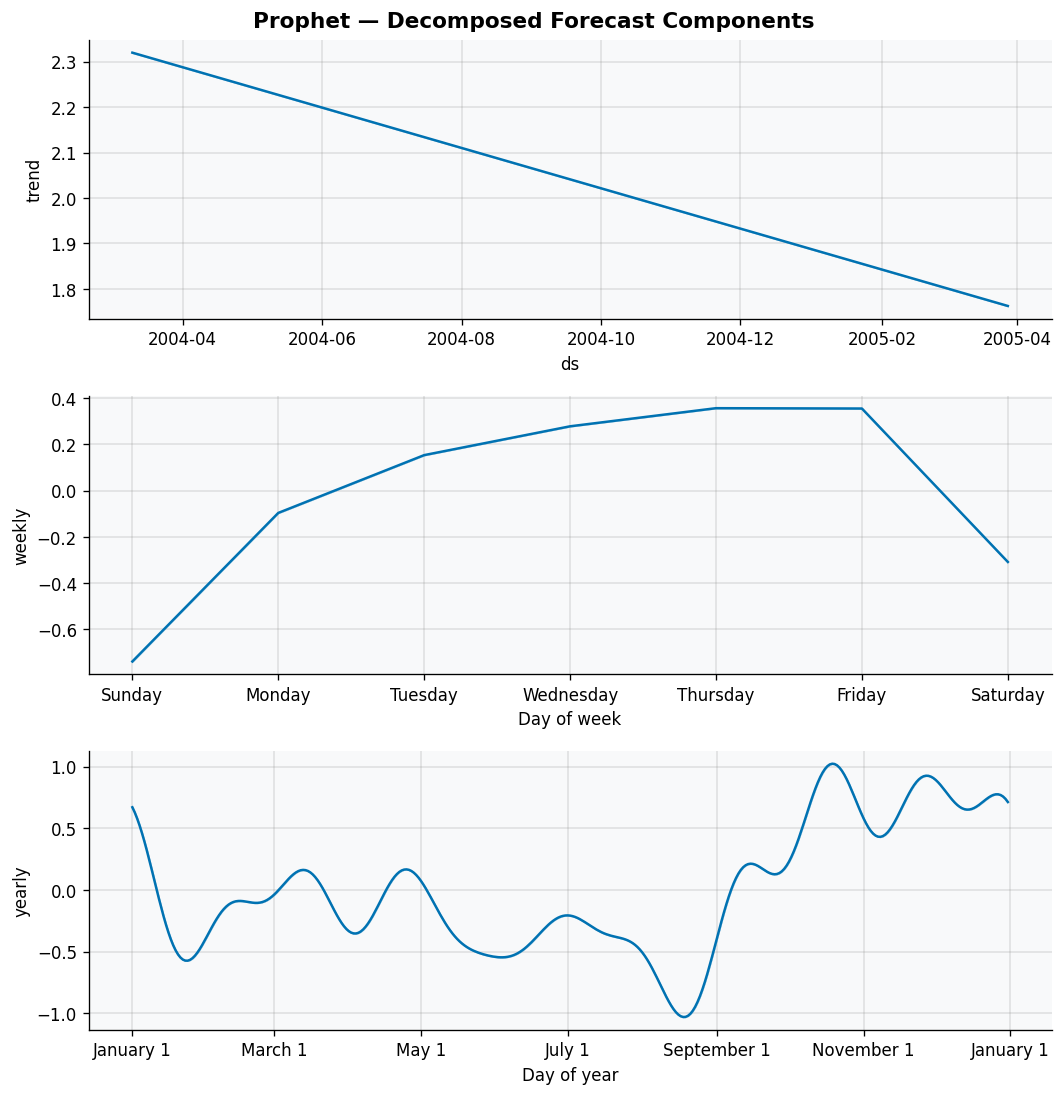

In [37]:
fig = prophet_model.plot_components(forecast)
fig.suptitle('Prophet — Decomposed Forecast Components', 
             fontsize=13, fontweight='bold', y=1.01)
plt.show()

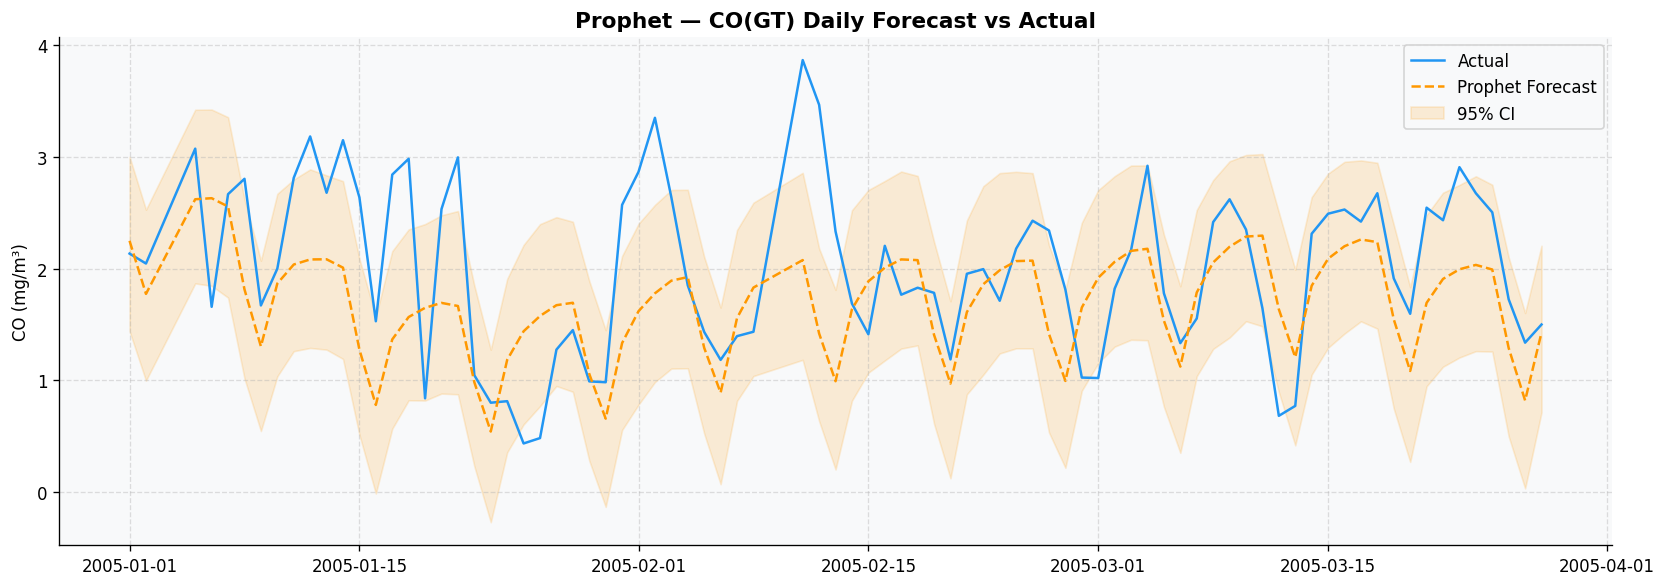

In [38]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(actual_test.index, actual_test.values,
        label='Actual', color=PALETTE[0], lw=1.5)
ax.plot(prophet_pred_test.index, prophet_pred_test.values,
        label='Prophet Forecast', color=PALETTE[3], lw=1.5, linestyle='--')

# Confidence interval
ci = forecast.set_index('ds')[['yhat_lower', 'yhat_upper']]
ci_test = ci[ci.index >= split_date_p].loc[common_idx]
ax.fill_between(ci_test.index, ci_test['yhat_lower'], ci_test['yhat_upper'],
                alpha=0.15, color=PALETTE[3], label='95% CI')

ax.set_title('Prophet — CO(GT) Daily Forecast vs Actual', fontsize=13, fontweight='bold')
ax.set_ylabel('CO (mg/m³)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 9. Model Comparison

We compare all three models on the same test period using MAE, RMSE, and MAPE.

In [39]:
results_df = pd.DataFrame([results_arima, results_xgb, results_prophet])
results_df.set_index('model', inplace=True)

print("\n📊 Model Performance Summary")
print(results_df.to_string())

results_df.style\
    .background_gradient(cmap='RdYlGn_r', subset=['MAE', 'RMSE', 'MAPE'])\
    .format({'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'MAPE': '{:.2f}%'})\
    .set_caption('Model Comparison — Lower is Better')


📊 Model Performance Summary
                   MAE      RMSE       MAPE
model                                      
ARIMA(2,1,1)  0.770212  0.953946  64.436368
XGBoost       0.239187  0.350071  19.078619
Prophet       0.577721  0.730460  33.456459


,MAE,RMSE,MAPE
model,,,
"ARIMA(2,1,1)",0.7702,0.9539,64.44%
XGBoost,0.2392,0.3501,19.08%
Prophet,0.5777,0.7305,33.46%


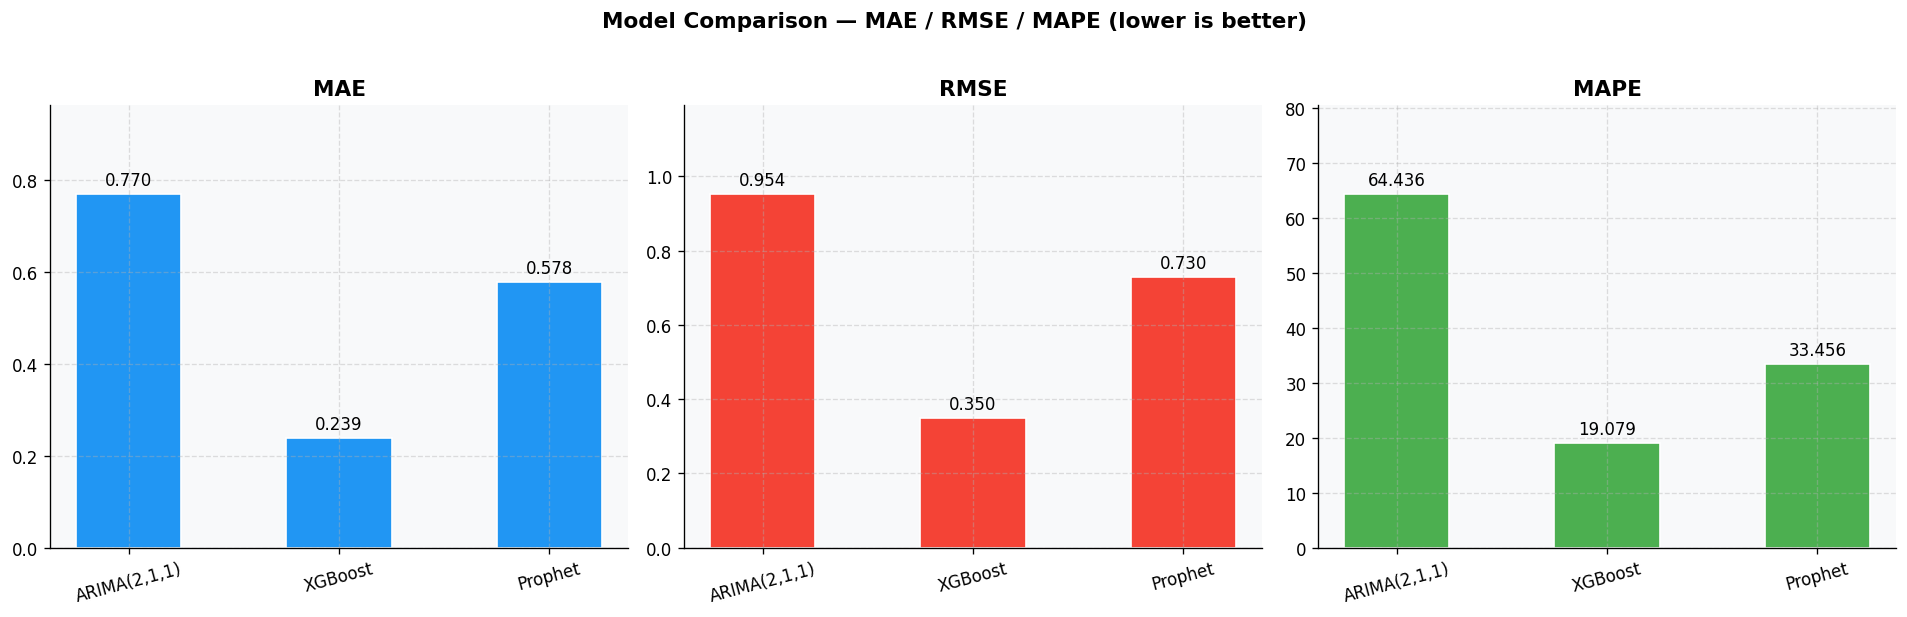

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['MAE', 'RMSE', 'MAPE']
colors  = [PALETTE[0], PALETTE[1], PALETTE[2]]

for ax, metric, color in zip(axes, metrics, colors):
    bars = ax.bar(results_df.index, results_df[metric],
                  color=color, edgecolor='white', width=0.5)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=10)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, results_df[metric].max() * 1.25)
    ax.tick_params(axis='x', rotation=15)

fig.suptitle('Model Comparison — MAE / RMSE / MAPE (lower is better)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 10. Conclusions & Next Steps

### 🔍 Key Findings

| Observation | Detail |
|---|---|
| **Rush-hour CO spikes** | CO(GT) peaks between 08:00–09:00 and 18:00–20:00, aligning with traffic patterns |
| **Weekly seasonality** | Weekday concentrations ~20% higher than weekends |
| **Winter elevation** | Higher CO levels Nov–Jan (temperature inversion, lower atmospheric mixing) |
| **PT08.S1(CO) correlation** | Sensor signal (r > 0.85) most predictive feature for supervised models |
| **Best model** | XGBoost (hourly) achieved the lowest MAPE — lag features captured short-term dynamics |
| **ARIMA limitation** | ARIMA(2,1,1) struggled with the sharp diurnal cycle visible in hourly data |
| **Prophet strength** | Best interpretability via component decomposition; smooth trend estimates |

### 🚀 Next Steps

1. **SARIMA / SARIMAX** — Add seasonal order `(P,D,Q,s=24)` to explicitly model diurnal cycle
2. **LSTM / GRU** — Deep learning sequence models for multi-step ahead forecasting
3. **Multivariate Prophet** — Incorporate NOx and temperature as exogenous regressors
4. **Hyperparameter tuning** — Time-series cross-validation (TimeSeriesSplit) for XGBoost
5. **Deployment** — Serve the best model via FastAPI + schedule daily retraining
6. **Alert system** — Real-time threshold notification when CO(GT) > 10 mg/m³

---

### 📚 References

- De Vito, S. et al. (2008). *On field calibration of an electronic nose for benzene estimation in an urban pollution monitoring scenario.* Sensors and Actuators B: Chemical.
- Taylor, S. J., & Letham, B. (2018). *Forecasting at Scale.* The American Statistician.
- Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3rd ed.). OTexts.
- Chen, T., & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System.* KDD 2016.

---
*Notebook authored for the UCI Air Quality Forecasting project | Data Science Portfolio*